In [7]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc
from matplotlib.colors import to_rgb, rgb_to_hsv, hsv_to_rgb
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import os


In [8]:
def dotted_style(i):
    base_styles = ['-', '--', '-.', ':']  # standard matplotlib styles
    if i < len(base_styles):
        return base_styles[i]
    else:
        # for i >= 4, generate sparser custom dash patterns
        dash_length = 1
        gap_length = 4 + (i-4)*2  # increase gap with i
        return (0, (dash_length, gap_length))

def vary_brightness(base_color, i, n, v_min=0.4, v_max=1.0):
    rgb = to_rgb(base_color)
    hsv = rgb_to_hsv(rgb)
    
    # interpolate brightness (value channel)
    t = i / (n - 1) if n > 1 else 0
    hsv[2] = v_min + (v_max - v_min) * t
    
    return hsv_to_rgb(hsv)

/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:103: RuntimeWarning: divide by zero encountered in divide
  ax_roc_tag.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:103: RuntimeWarning: divide by zero encountered in divide
  ax_roc_tag.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:103: RuntimeWarning: divide by zero encountered in divide
  ax_roc_tag.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
0     5.667992
1     5.460470
2     5.421030
3     5.396676
4     5.378801
5     5.364113
6     5.351217
7     5.339521
8     5.328403
9     5.317709
10    5.307545
11    5.297568
12    5.287891
13    5.278472
14    5.269285
15    5.260439
16    5.251986
17    5.243988
18    5.236632
19    5.230000
Name: train_loss, dtype: float64
20


/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:103: RuntimeWarning: divide by zero encountered in divide
  ax_roc_tag.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:103: RuntimeWarning: divide by zero encountered in divide
  ax_roc_tag.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:103: RuntimeWarning: divide by zero encountered in divide
  ax_roc_tag.plot(tpr, 1/fpr,
/tmp/eu732103/login23-g-1_66429/ipykernel_353000/1368387543.py:99: RuntimeWarning: divide by zero encountered

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
0     5.667992
1     5.460470
2     5.421030
3     5.396676
4     5.378801
5     5.364113
6     5.351217
7     5.339521
8     5.328403
9     5.317709
10    5.307545
11    5.297568
12    5.287891
13    5.278472
14    5.269285
15    5.260439
16    5.251986
17    5.243988
18    5.236632
19    5.230000
Name: train_loss, dtype: float64
20


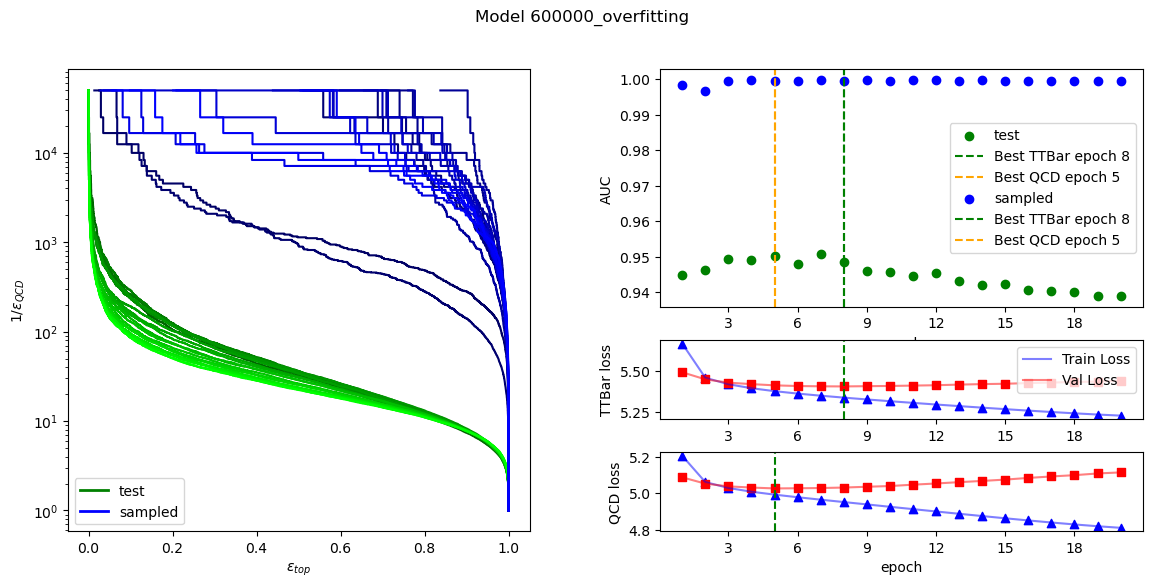

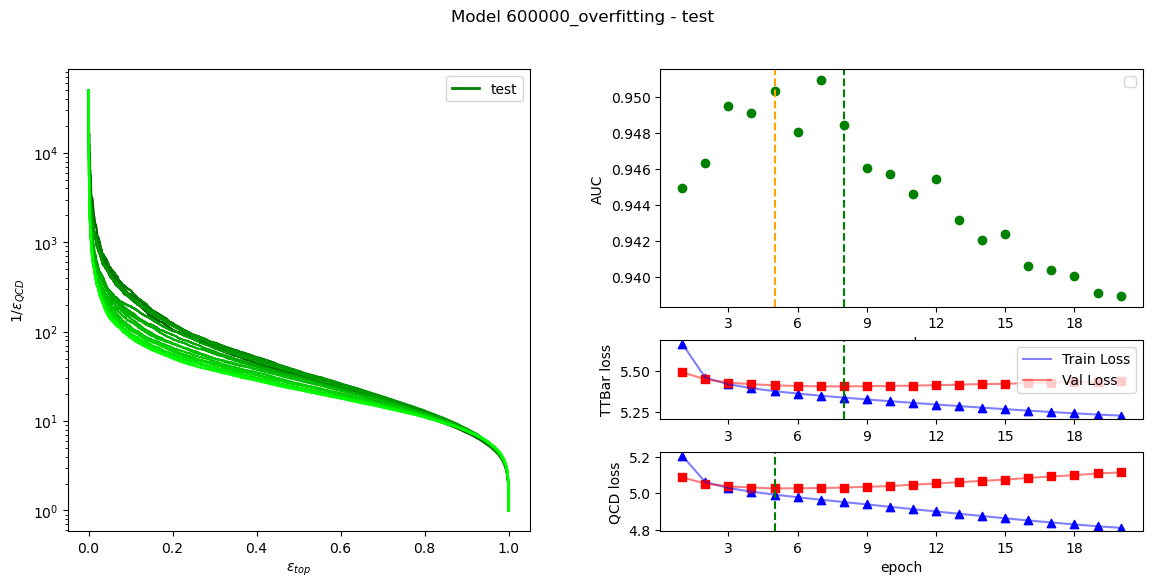

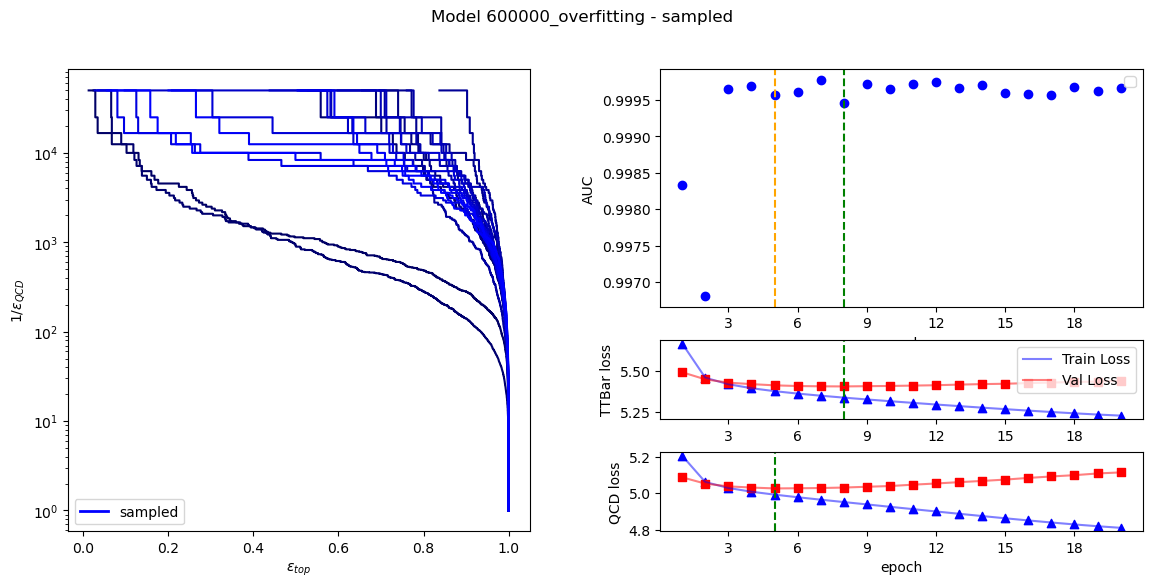

In [ ]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

tags = ["test", "sampled"]
colors = ["green","blue"]

n_jets = 600000
batch_size = 100

base = "/hpcwork/rwth0934/hep_foundation_model/classification"
base_train = "/hpcwork/rwth0934/hep_foundation_model/training"

trainings_run = "600000_overfitting"

CLASSES = ["QCD", "TTBar"]

fig = plt.figure(figsize=(14, 6))

gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[1, 1],
    height_ratios=[3, 1, 1],  # AUC is twice each loss panel
    wspace=0.25, hspace=0.25
)

ax_roc = fig.add_subplot(gs[:, 0])   # spans all 3 rows
ax_auc = fig.add_subplot(gs[0, 1])
ax_loss_ttbar = fig.add_subplot(gs[1, 1], sharex = ax_auc)
ax_loss_qcd   = fig.add_subplot(gs[2, 1], sharex = ax_auc)

ax_roc.set_box_aspect(1)

ttbar_loss = pd.read_csv(f"{base_train}/{trainings_run}/TTBar_training_log.csv")
qcd_loss   = pd.read_csv(f"{base_train}/{trainings_run}/QCD_training_log.csv")

# Filter loss data to only include values corresponding to the epochs
steps_to_keep = [(epoch) * (int(n_jets//batch_size)) for epoch in epochs]
ttbar_loss = ttbar_loss[ttbar_loss['step'].isin(steps_to_keep)].reset_index(drop=True)
qcd_loss = qcd_loss[qcd_loss['step'].isin(steps_to_keep)].reset_index(drop=True)

x_tt = epochs
x_qcd = epochs

for j in range(len(tags)):

    fig_tag = plt.figure(figsize=(14, 6))

    gs_tag = fig_tag.add_gridspec(
        nrows=3, ncols=2,
        width_ratios=[1, 1],
        height_ratios=[3, 1, 1],  # AUC is twice each loss panel
        wspace=0.25, hspace=0.25
    )

    ax_roc_tag = fig_tag.add_subplot(gs_tag[:, 0])   # spans all 3 rows
    ax_auc_tag = fig_tag.add_subplot(gs_tag[0, 1])
    ax_loss_ttbar_tag = fig_tag.add_subplot(gs_tag[1, 1], sharex = ax_auc_tag)
    ax_loss_qcd_tag   = fig_tag.add_subplot(gs_tag[2, 1], sharex = ax_auc_tag)

    ax_roc_tag.set_box_aspect(1)

    auc_scores = []

    for i in range(len(epochs)):
        skip = False

        folder = f"{base}/{trainings_run}/heatmap_{tags[j]}/points/tmp_{epochs[i]}_{epochs[i]}"

        scores, labels = [], []

        for k, cls in enumerate(CLASSES):

            if not os.path.exists(f"{folder}/TTBar_{cls}.csv") or not os.path.exists(f"{folder}/QCD_{cls}.csv"):
                print(f"Warning: Missing files for epoch {epochs[i]} and class {cls}. Skipping.")

                auc_scores = np.append(auc_scores, np.nan)
                skip = True

                break
            else:
            
                top = pd.read_csv(f"{folder}/TTBar_{cls}.csv")
                qcd = pd.read_csv(f"{folder}/QCD_{cls}.csv")

                s = top["probs"] - qcd["probs"]

                scores.append(s.values)
                labels.append(np.full(len(s), k))

        if skip:
            continue

        scores = np.concatenate(scores)
        labels = np.concatenate(labels)

        fpr, tpr, thresholds = roc_curve(labels, scores)

        roc_auc = auc(fpr, tpr)

        ax_roc.plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        ax_roc_tag.plot(tpr, 1/fpr, 
            color = vary_brightness(colors[j], i, len(epochs))) 

        auc_scores = np.append(auc_scores, roc_auc)

    legend_elements = [
        Line2D([0], [0], color=colors[j], lw=2, label=f"{tags[j]}")
    ]
    ax_roc_tag.legend(handles = legend_elements)

    ax_roc_tag.set_yscale("log")
    ax_roc_tag.set_xlabel(r"$\epsilon_{top}$")
    ax_roc_tag.set_ylabel(r"$1/\epsilon_{QCD}$") 

    ax_auc_tag.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax_auc_tag.set_xlabel("epoch")
    ax_auc_tag.set_ylabel("AUC")

    ax_auc_tag.legend()

    fig_tag.suptitle(f"Model {trainings_run} - {tags[j]}")

    #plot ttbar loss
    length = min(len(x_tt), len(ttbar_loss["train_loss"]))
    print(x_tt)
    print(ttbar_loss["train_loss"])

    best_epoch_tt = epochs[np.argmin(ttbar_loss["val_loss"])]

    print(length)

    ax_loss_ttbar_tag.scatter(x_tt[:length], ttbar_loss["train_loss"][:length], color = "blue", marker = "^")
    ax_loss_ttbar_tag.plot(x_tt[:length], ttbar_loss["train_loss"][:length], alpha = 0.5, color = "blue", label = "Train Loss")  # optional line plot

    ax_loss_ttbar_tag.scatter(x_tt[:length], ttbar_loss["val_loss"][:length], color = "red", marker = "s")
    ax_loss_ttbar_tag.plot(x_tt[:length], ttbar_loss["val_loss"][:length], alpha = 0.5, color = "red", label = "Val Loss")  # optional line plot

    ax_loss_ttbar_tag.axvline(x=best_epoch_tt, color='green', linestyle='--')

    #plot qcd loss
    best_epoch_qcd = epochs[np.argmin(qcd_loss["val_loss"])]

    ax_loss_qcd_tag.scatter(x_qcd[:length], qcd_loss["train_loss"][:length], color = "blue", marker = "^")
    ax_loss_qcd_tag.plot(x_qcd[:length], qcd_loss["train_loss"][:length], alpha = 0.5, color = "blue")  # optional line plot

    ax_loss_qcd_tag.scatter(x_qcd[:length], qcd_loss["val_loss"][:length], color = "red", marker = "s")
    ax_loss_qcd_tag.plot(x_qcd[:length], qcd_loss["val_loss"][:length], alpha = 0.5, color = "red")  # optional line plot

    ax_loss_qcd_tag.axvline(x=best_epoch_qcd, color='orange', linestyle='--')

    ax_loss_ttbar_tag.set_ylabel("TTBar loss")
    ax_loss_qcd_tag.set_ylabel("QCD loss")
    ax_loss_qcd_tag.set_xlabel("epoch")

    ax_loss_ttbar_tag.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax_loss_qcd_tag.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax_loss_ttbar_tag.legend()

    ax_auc.scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

    ax_auc_tag.scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

    ax_auc_tag.axvline(x=best_epoch_tt, color='green', linestyle='--', label = f"Best TTBar epoch {best_epoch_tt}")
    ax_auc_tag.axvline(x=best_epoch_qcd, color='orange', linestyle='--', label = f"Best QCD epoch {best_epoch_qcd}")

    os.makedirs("plots", exist_ok = True)
    fig_tag.savefig(f"plots/roc_evol_{trainings_run}_{tags[j]}.png", dpi = 300, bbox_inches = "tight")

#plot ttbar loss
length = min(len(x_tt), len(ttbar_loss["train_loss"]))

best_epoch_tt = epochs[np.argmin(ttbar_loss["val_loss"])]

ax_loss_ttbar.scatter(x_tt[:length], ttbar_loss["train_loss"][:length], color = "blue", marker = "^")
ax_loss_ttbar.plot(x_tt[:length], ttbar_loss["train_loss"][:length], alpha = 0.5, color = "blue", label = "Train Loss")  # optional line plot

ax_loss_ttbar.scatter(x_tt[:length], ttbar_loss["val_loss"][:length], color = "red", marker = "s")
ax_loss_ttbar.plot(x_tt[:length], ttbar_loss["val_loss"][:length], alpha = 0.5, color = "red", label = "Val Loss")  # optional line plot

ax_loss_ttbar.axvline(x=best_epoch_tt, color='green', linestyle='--')

#plot qcd loss
best_epoch_qcd = epochs[np.argmin(qcd_loss["val_loss"])]

ax_loss_qcd.scatter(x_qcd[:length], qcd_loss["train_loss"][:length], color = "blue", marker = "^")
ax_loss_qcd.plot(x_qcd[:length], qcd_loss["train_loss"][:length], alpha = 0.5, color = "blue")  # optional line plot

ax_loss_qcd.scatter(x_qcd[:length], qcd_loss["val_loss"][:length], color = "red", marker = "s")
ax_loss_qcd.plot(x_qcd[:length], qcd_loss["val_loss"][:length], alpha = 0.5, color = "red")  # optional line plot

ax_loss_qcd.axvline(x=best_epoch_qcd, color='orange', linestyle='--')

ax_loss_ttbar.set_ylabel("TTBar loss")
ax_loss_qcd.set_ylabel("QCD loss")
ax_loss_qcd.set_xlabel("epoch")

ax_loss_ttbar.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_loss_qcd.xaxis.set_major_locator(MaxNLocator(integer=True))

ax_loss_ttbar.legend()

ax_auc.axvline(x=best_epoch_tt, color='green', linestyle='--', label = f"Best TTBar epoch {best_epoch_tt}")
ax_auc.axvline(x=best_epoch_qcd, color='orange', linestyle='--', label = f"Best QCD epoch {best_epoch_qcd}")

legend_elements = [
    Line2D([0], [0], color=colors[l], lw=2, label=f"{tags[l]}")
    for l in range(len(tags))
]

ax_roc.legend(handles = legend_elements)

ax_roc.set_yscale("log")

ax_roc.set_xlabel(r"$\epsilon_{top}$")
ax_roc.set_ylabel(r"$1/\epsilon_{QCD}$")

ax_auc.set_xlabel("epoch")
ax_auc.set_ylabel("AUC")

ax_auc.xaxis.set_major_locator(MaxNLocator(integer=True))

ax_auc.legend()

fig.suptitle(f"Model {trainings_run}")

os.makedirs("plots", exist_ok = True)

fig.savefig(f"plots/roc_evol_{trainings_run}.png", dpi = 300, bbox_inches = "tight")